In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("iris.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (150, 5)


In [3]:
print("First 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

First 5 rows:


,150,4,setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Column names:
['150', '4', 'setosa', 'versicolor', 'virginica']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   150         150 non-null    float64
 1   4           150 non-null    float64
 2   setosa      150 non-null    float64
 3   versicolor  150 non-null    float64
 4   virginica   150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [4]:
df.columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

print("Column names updated successfully!")
print(df.columns.tolist())

Column names updated successfully!
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate rows:
1


In [6]:
# Remove duplicate rows
before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("Duplicate rows removed:", before - after)
print("Dataset shape after removing duplicates:", df.shape)

Duplicate rows removed: 1
Dataset shape after removing duplicates: (149, 5)


In [7]:
print("First 3 rows:")
display(df.head(3))

print("\nData types:")
print(df.dtypes)

First 3 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0



Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species           int64
dtype: object


In [8]:
print("Species classes:")
print(df["species"].unique())

print("\nNumber of samples in each class:")
print(df["species"].value_counts().sort_index())

Species classes:
[0 1 2]

Number of samples in each class:
species
0    50
1    50
2    49
Name: count, dtype: int64


In [9]:
# Check outliers using IQR method

numeric_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)

IQR = Q3 - Q1

outliers = (
    (df[numeric_columns] < (Q1 - 1.5 * IQR)) |
    (df[numeric_columns] > (Q3 + 1.5 * IQR))
).sum()

print("Outliers in each feature:")
print(outliers)

Outliers in each feature:
sepal_length    0
sepal_width     4
petal_length    0
petal_width     0
dtype: int64


In [10]:
X = df[[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]]

y = df["species"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (149, 4)
Target shape: (149,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (119, 4)
Testing features: (30, 4)
Training target: (119,)
Testing target: (30,)


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled training data shape: (119, 4)
Scaled testing data shape: (30, 4)


In [13]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [14]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [15]:
# Make predictions
y_pred = logistic_model.predict(X_test_scaled)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")

Logistic Regression Results
---------------------------
Accuracy  : 0.9333
Precision : 0.9333
Recall    : 0.9333


In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


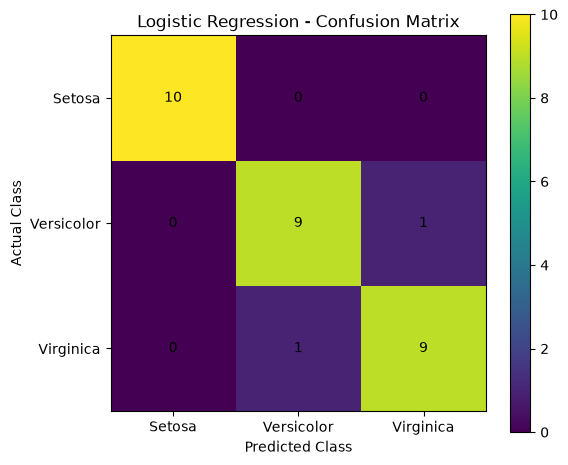

In [17]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1, 2], ["Setosa", "Versicolor", "Virginica"])
plt.yticks([0, 1, 2], ["Setosa", "Versicolor", "Virginica"])

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

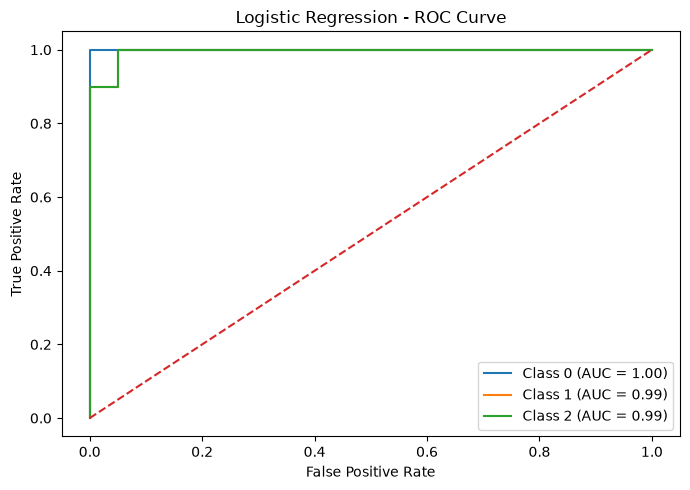

In [18]:
# ROC Curve and AUC for multiclass classification

y_test_binary = pd.get_dummies(y_test).values
y_prob = logistic_model.predict_proba(X_test_scaled)

plt.figure(figsize=(7, 5))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_binary[:, i], y_prob[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {class_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average="weighted")
rf_recall = recall_score(y_test, rf_pred, average="weighted")

print("Random Forest Results")
print("---------------------")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")

Random Forest Results
---------------------
Accuracy  : 0.9333
Precision : 0.9333
Recall    : 0.9333


In [20]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "Precision": [precision, rf_precision],
    "Recall": [recall, rf_recall]
})

display(comparison)

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.933333,0.933333,0.933333
1,Random Forest,0.933333,0.933333,0.933333


In [21]:
print("Logistic Regression - Classification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Setosa", "Versicolor", "Virginica"]
))

Logistic Regression - Classification Report
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [23]:
print("FINAL FINDINGS")
print("=" * 50)

print("1. Dataset was cleaned by removing the metadata row and one duplicate record.")
print("2. No missing values were found.")
print("3. Four numerical features were used for classification.")
print("4. Feature scaling was performed using StandardScaler.")
print(f"5. Logistic Regression Accuracy: {accuracy:.2%}")
print(f"6. Logistic Regression Precision: {precision:.2%}")
print(f"7. Logistic Regression Recall: {recall:.2%}")
print(f"8. Random Forest Accuracy: {rf_accuracy:.2%}")
print("9. Both models achieved the same performance on the test set.")
print("10. Logistic Regression achieved excellent ROC-AUC performance across all classes.")

FINAL FINDINGS
1. Dataset was cleaned by removing the metadata row and one duplicate record.
2. No missing values were found.
3. Four numerical features were used for classification.
4. Feature scaling was performed using StandardScaler.
5. Logistic Regression Accuracy: 93.33%
6. Logistic Regression Precision: 93.33%
7. Logistic Regression Recall: 93.33%
8. Random Forest Accuracy: 93.33%
9. Both models achieved the same performance on the test set.
10. Logistic Regression achieved excellent ROC-AUC performance across all classes.
